In [6]:
import xarray as xr
import numpy as np
import importlib.util
from pathlib import Path

#run from the repo root or Scripts directory
root = Path.cwd()
if root.name == 'Scripts':
    root = root.parent

#local plotting functions
spec = importlib.util.spec_from_file_location('plot_init', root / 'functions' / 'plot_init.py')
plot_init = importlib.util.module_from_spec(spec)
spec.loader.exec_module(plot_init)


In [7]:
fn = root / 'Data' / 'wave_energy.nc'

ds = xr.open_dataset(fn)
Emean = ds['Emean'].values
Emean = np.where(np.isnan(Emean), 0, Emean)  # Replace NaNs with zeros for plotting
Ediff = ds['Ediff'].values
Ediff = np.where(np.isnan(Ediff), 0, Ediff)  # Replace NaNs with zeros for plotting
lat,lon = ds['latitude'].values, ds['longitude'].values
elements = ds['tri'].values - 1 
ds.close()

In [8]:
#plotting
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec
import cartopy.feature as cfeature
import cmocean
from matplotlib.colors import LogNorm  



In [9]:
def make_it_nice(ax,extent,shapes=None):
    # Keep political borders on top; place land beneath filled contours
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=1, zorder=3)
    ax.add_feature(cfeature.LAND, facecolor='gainsboro', edgecolor='none', zorder=-2)
    ax.set_facecolor('gainsboro')

def plot_E(ax,triang,Energy):
    levels = np.logspace(np.log10(1e2), np.log10(1e8), num=25)
    cmap = cmocean.cm.thermal
    
    # Rasterize artists below zorder 0 (useful for smaller PDF/SVG output)
    ax.set_rasterization_zorder(0)
    cf = ax.tricontourf(
        triang, Energy/1e3 + 1e-1, levels=levels, cmap=cmap,
        norm=LogNorm(vmin=levels[0], vmax=levels[-1]),
        extend='both', zorder=-1
    )
    return cf

def plot_diff_log(ax,triang,diff_E):
    diff_E = diff_E*-1 + 1e-9 #small offset to avoid log(0)
    diff_levels = np.logspace(np.log10(1e-1), np.log10(50), num=25)
    diff_map = cmocean.cm.tempo
    
    # Rasterize artists below zorder 0 (useful for smaller PDF/SVG output)
    ax.set_rasterization_zorder(0)
    cf = ax.tricontourf(
        triang, diff_E, levels=diff_levels, cmap=diff_map,
        norm=LogNorm(vmin=diff_levels[0], vmax=diff_levels[-1]),
        extend='both', zorder=-1
    )
    return cf






/Users/martin.henke/anaconda3/envs/PISCES/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/martin.henke/anaconda3/envs/PISCES/lib/python3.13/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/Users/martin.henke/anaconda3/envs/PISCES/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/martin.henke/anaconda3/envs/PISCES/lib/python3.13/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/Users/martin.henke/anaconda3/envs/PISCES/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/martin.

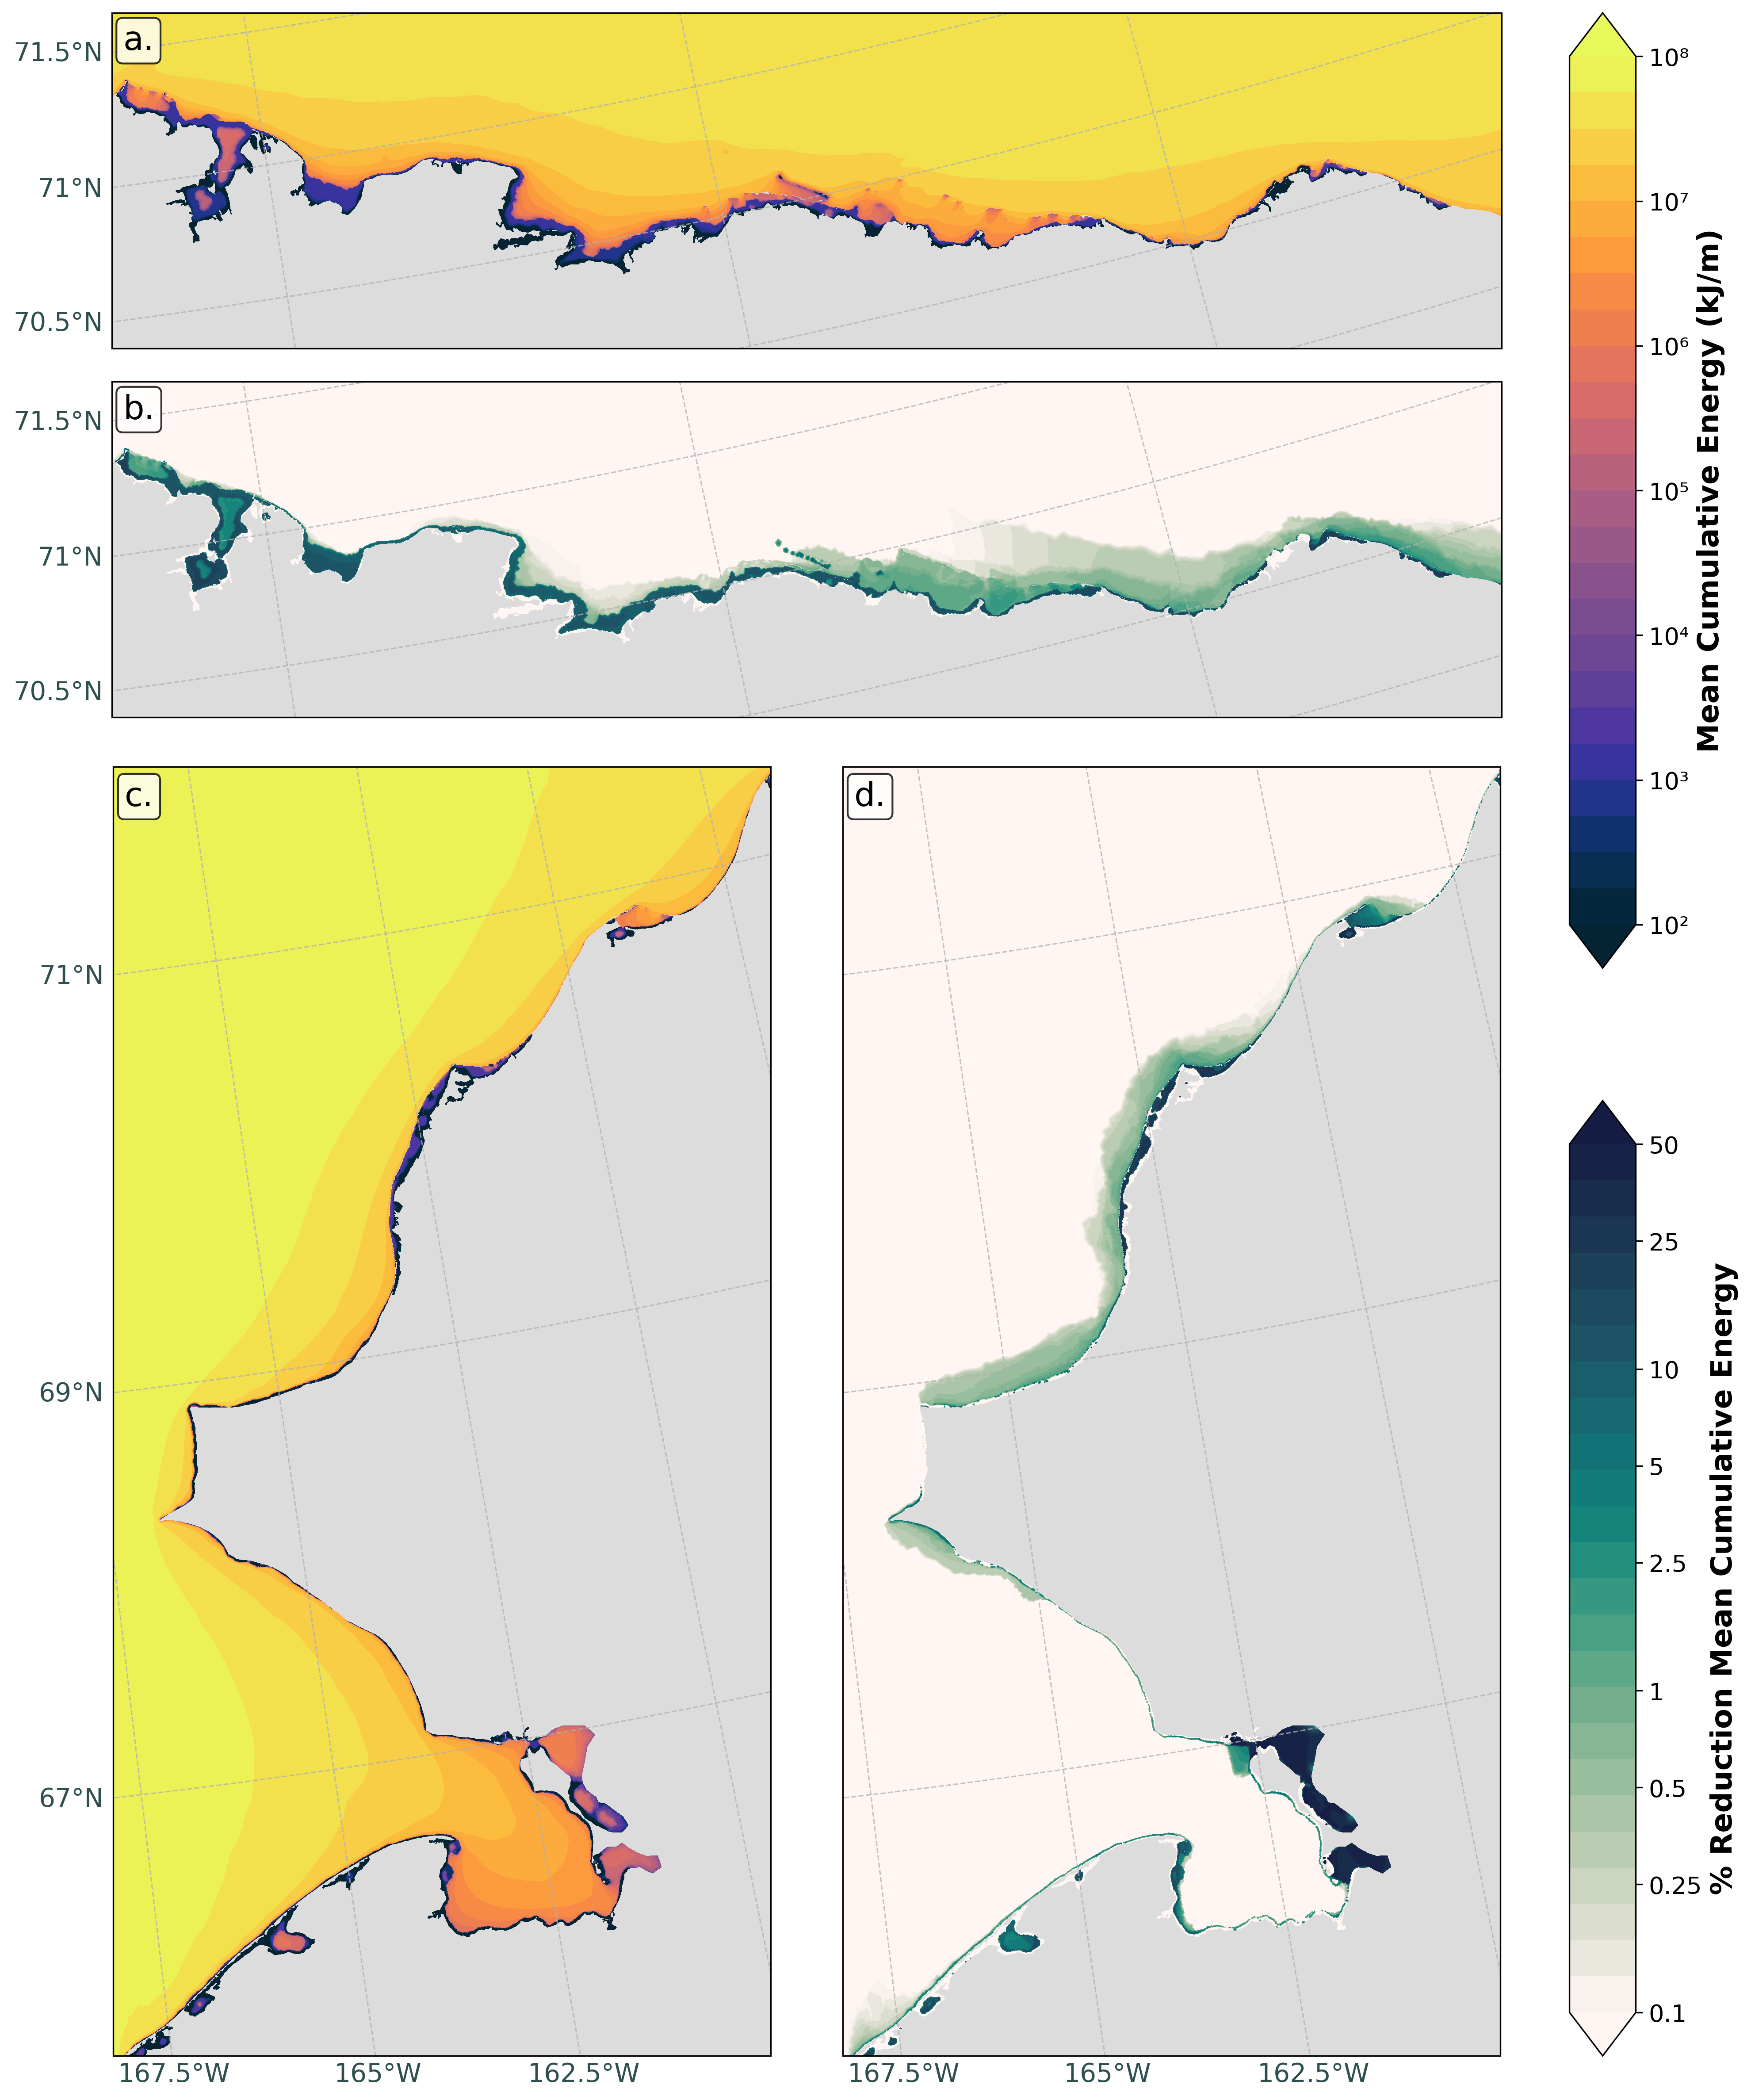

In [10]:
#Initialize figure
fig = plt.figure(figsize=(20, 20),dpi=300)
gs0 = gridspec.GridSpec(2, 1, height_ratios=[1,1.83], hspace=0.05)

######## Beaufort coast plots ##########
#setup the projection and coordinates 
beau_extent,beau_rotation = plot_init.get_extent(option='beaufort')
beau_proj = plot_init.get_projection(beau_extent, rotation=beau_rotation)
beau_triang = plot_init.transformed_triangulation(lon, lat, elements, beau_proj)

gs00 = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs0[0], hspace=0.1)
ax_beau0 = fig.add_subplot(gs00[0, 0], projection=beau_proj)
ax_beau0.set_extent(beau_extent, crs=ccrs.PlateCarree())
ax_beau1 = fig.add_subplot(gs00[1, 0], projection=beau_proj)
ax_beau1.set_extent(beau_extent, crs=ccrs.PlateCarree())

cfe0 = plot_E(ax_beau0,beau_triang,Emean)
cfe1 = plot_diff_log(ax_beau1,beau_triang,Ediff)

make_it_nice(ax_beau0,beau_extent)
make_it_nice(ax_beau1,beau_extent)

gl = plot_init.get_gridlines(ax_beau0,region='beaufort')
gl = plot_init.gl_styler(gl,l=True,fontsize=14)
gl = plot_init.get_gridlines(ax_beau1,region='beaufort')
gl = plot_init.gl_styler(gl,l=True,fontsize=14)



########## Chukchi coast plots ##########
#setup the projection and coordinates
chuk_extent,chuk_rotation = plot_init.get_extent(option='chukchi')
chuk_proj = plot_init.get_projection(chuk_extent, rotation=chuk_rotation)
chuk_triang = plot_init.transformed_triangulation(lon, lat, elements, chuk_proj)

gs01 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs0[1], wspace=-0.45)
ax_chuk0 = fig.add_subplot(gs01[0, 0], projection=chuk_proj)
ax_chuk0.set_extent(chuk_extent, crs=ccrs.PlateCarree())
ax_chuk1 = fig.add_subplot(gs01[0, 1], projection=chuk_proj)
ax_chuk1.set_extent(chuk_extent, crs=ccrs.PlateCarree())


cf_E = plot_E(ax_chuk0,chuk_triang,Emean)
cf_diff = plot_diff_log(ax_chuk1,chuk_triang,Ediff)

gl = plot_init.get_gridlines(ax_chuk0,region='chukchi')
gl = plot_init.gl_styler(gl,b=True,l=True,fontsize=14)
gl = plot_init.get_gridlines(ax_chuk1,region='chukchi')
gl = plot_init.gl_styler(gl,b=True,fontsize=14)

make_it_nice(ax_chuk0,chuk_extent)
make_it_nice(ax_chuk1,chuk_extent)


#colorbars 
xorg, yorg = 0.8, 0.11
xlen, ylen = 0.025, 0.36
cbar_ax1 = fig.add_axes([xorg, yorg, xlen, ylen])
cbar_diff = plt.colorbar(cf_diff, cax=cbar_ax1, orientation='vertical')
cbar_diff.set_label('% Reduction Mean Cumulative Energy', fontsize=16,fontweight='bold')
ticks_diff = [0.1,0.25,0.5,1,2.5,5,10,25,50]  # Adjust the step for fewer ticks
cbar_diff.set_ticks(ticks_diff)
cbar_diff.ax.set_yticklabels([str(t) for t in ticks_diff], fontsize=13)   

cbar_ax2 = fig.add_axes([xorg, yorg+ylen+0.05, xlen, ylen]) # [left, bottom, width, height]
cbar_E = plt.colorbar(cf_E, cax=cbar_ax2, orientation='vertical')
cbar_E.set_label('Mean Cumulative Energy (kJ/m)', fontsize=16,fontweight='bold')
ticks_E = np.logspace(np.log10(1e2), np.log10(1e8), num=7)
cbar_E.set_ticks(ticks_E)
def format_sci(value):
    exp = int(np.log10(value))
    superscripts = str.maketrans("0123456789", "⁰¹²³⁴⁵⁶⁷⁸⁹")
    return f"10{str(exp).translate(superscripts)}"

cbar_E.ax.set_yticklabels([format_sci(t) for t in ticks_E], fontsize=13, rotation=0)

## Suplot labels
plot_init.add_label(ax_beau0, 'a.', dy = 0.89,dx=0.008)
plot_init.add_label(ax_beau1, 'b.',dy = 0.89,dx=0.008)
plot_init.add_label(ax_chuk0, 'c.', dy = 0.97,dx=0.0175)
plot_init.add_label(ax_chuk1, 'd.',dy = 0.97,dx=0.0175)

plt.savefig(root / 'Figures' / 'wave_energy.png',bbox_inches='tight')